In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset (Since both files are in the same folder, this is perfect)
dataset = pd.read_csv("Life Expectancy Data.csv")

# 2. Fix the hidden spaces in the column names
dataset.columns = dataset.columns.str.strip()

# 3. Change the text to numbers (Developing = 0, Developed = 1)
dataset['Status'] = dataset['Status'].map({'Developing': 0, 'Developed': 1})

# 4. Drop the 'Country' column and the duplicate columns
dataset = dataset.drop(columns=['Country', 'infant deaths', 'thinness 5-9 years'])

# 5. Fill in the blank missing data with the average
dataset['Life expectancy'].fillna(dataset['Life expectancy'].mean(), inplace=True)
dataset.fillna(dataset.mean(), inplace=True)

# Print the final shape to prove it's clean and full
print("Cleaned dataset shape:", dataset.shape)
dataset.head()

ModuleNotFoundError: No module named 'pandas'

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Separate the Answers (y) from the Questions (x)
x = dataset.drop(columns=['Life expectancy'])
y = dataset['Life expectancy']

# 2. Hide 20% of the data for testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Build the Random Forest (100 Trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 4. Train the model (The Heavy Lifting)
rf_model.fit(x_train, y_train)

# 5. Take the exam and print the score
rf_pred = rf_model.predict(x_test)
print("Awesome! New Random Forest Score:", r2_score(y_test, rf_pred))

ModuleNotFoundError: No module named 'sklearn'

In [1]:
# 1. Extract the internal ranking from the model
importances = rf_model.feature_importances_

# 2. Match the scores to the column names
feature_ranking = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importances
})

# 3. Print the top 10 factors
print("Top 10 Most Important Factors for Life Expectancy:")
print(feature_ranking.sort_values(by='Importance', ascending=False).head(10))

# 4. Draw the Heatmap (Your Exploratory Data Analysis)
plt.figure(figsize=(14,10))
sns.heatmap(dataset.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

NameError: name 'rf_model' is not defined

In [ ]:
new_ds.dropna(inplace=True)
new_ds.shape

(1649, 20)

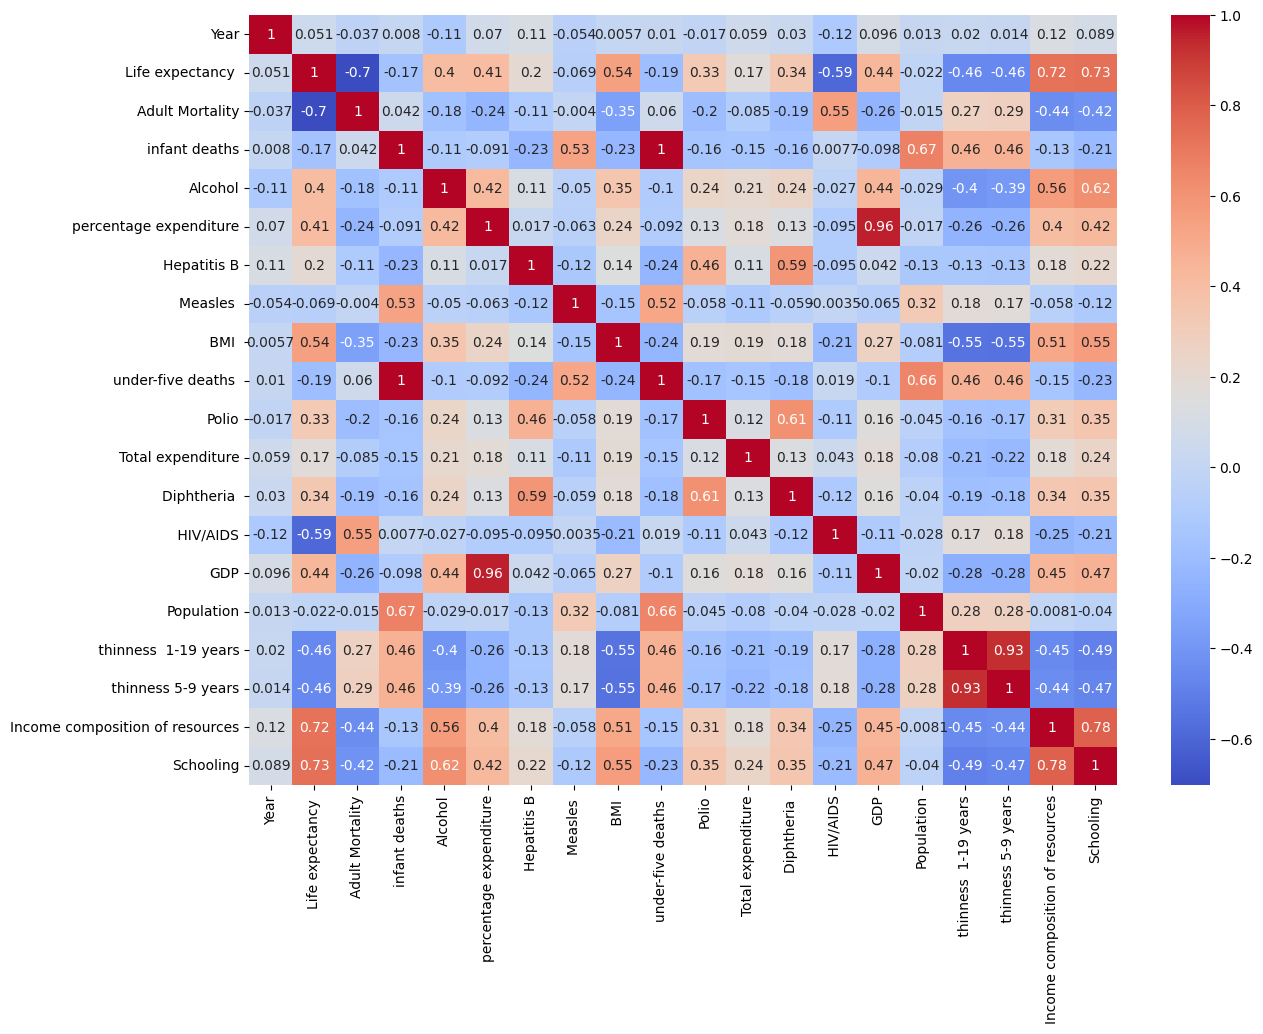

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(new_ds.corr(),annot=True,cmap="coolwarm")
plt.show()

In [ ]:

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

Scaled_data=scaler.fit_transform(new_ds)
new_scaled_ds=pd.DataFrame(Scaled_data,columns=new_ds.columns)
new_scaled_ds.head()


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1.000000,0.466667,0.362881,0.038750,0.0,0.003759,0.649485,0.008780,0.227696,0.039524,0.031250,0.543590,0.649485,0.0,0.004889,0.026074,0.630996,0.612100,0.511752,0.357576
1,0.933333,0.353333,0.373961,0.040000,0.0,0.003878,0.618557,0.003743,0.221039,0.040952,0.572917,0.545055,0.618557,0.0,0.005127,0.000253,0.642066,0.619217,0.508547,0.351515
2,0.866667,0.353333,0.369806,0.041250,0.0,0.003861,0.639175,0.003271,0.214381,0.042381,0.614583,0.541392,0.639175,0.0,0.005287,0.024525,0.649446,0.626335,0.502137,0.345455
3,0.800000,0.344444,0.375346,0.043125,0.0,0.004123,0.670103,0.021203,0.207723,0.044286,0.666667,0.569963,0.670103,0.0,0.005608,0.002857,0.656827,0.637011,0.494658,0.339394
4,0.733333,0.337778,0.379501,0.044375,0.0,0.000374,0.680412,0.022923,0.202397,0.046190,0.677083,0.522344,0.680412,0.0,0.000519,0.002302,0.667897,0.644128,0.485043,0.321212


In [ ]:
new_scaled_ds.columns

Index(['Year', 'Life expectancy ', 'Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
       ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [ ]:
final_dataset=new_scaled_ds[['Adult Mortality',' BMI ','Income composition of resources','Schooling',' HIV/AIDS','under-five deaths ']]
final_dataset.head(5)

,Adult Mortality,BMI,Income composition of resources,Schooling,HIV/AIDS,under-five deaths
0,0.362881,0.227696,0.511752,0.357576,0.0,0.039524
1,0.373961,0.221039,0.508547,0.351515,0.0,0.040952
2,0.369806,0.214381,0.502137,0.345455,0.0,0.042381
3,0.375346,0.207723,0.494658,0.339394,0.0,0.044286
4,0.379501,0.202397,0.485043,0.321212,0.0,0.046190


In [ ]:
final_dataset['Adult Mortality'] = 1 - final_dataset['Adult Mortality']
final_dataset[' HIV/AIDS'] = 1 - final_dataset[' HIV/AIDS']
final_dataset['under-five deaths '] = 1 - final_dataset['under-five deaths ']


final_dataset.head(5)

/tmp/ipykernel_169/911536137.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_dataset['Adult Mortality'] = 1 - final_dataset['Adult Mortality']
/tmp/ipykernel_169/911536137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_dataset[' HIV/AIDS'] = 1 - final_dataset[' HIV/AIDS']
/tmp/ipykernel_169/911536137.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

,Adult Mortality,BMI,Income composition of resources,Schooling,HIV/AIDS,under-five deaths
0,0.637119,0.227696,0.511752,0.357576,1.0,0.960476
1,0.626039,0.221039,0.508547,0.351515,1.0,0.959048
2,0.630194,0.214381,0.502137,0.345455,1.0,0.957619
3,0.624654,0.207723,0.494658,0.339394,1.0,0.955714
4,0.620499,0.202397,0.485043,0.321212,1.0,0.953810


In [ ]:
weights = {
    "Adult Mortality": 0.25,
    "Schooling": 0.20,
    "Income composition of resources": 0.10,
    " HIV/AIDS": 0.20,
    " BMI ": 0.10,
    "under-five deaths ": 0.15
}

In [ ]:
final_dataset["Health_Score"] = (
      final_dataset["Adult Mortality"] * weights["Adult Mortality"]
    + final_dataset["Schooling"] * weights["Schooling"]
    + final_dataset["Income composition of resources"] * weights["Income composition of resources"]
    + final_dataset[" HIV/AIDS"] * weights[" HIV/AIDS"]
    + final_dataset[" BMI "] * weights[" BMI "]+
      final_dataset["under-five deaths "] * weights["under-five deaths "]
)

/tmp/ipykernel_169/1833604618.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_dataset["Health_Score"] = (


In [ ]:
final_dataset["Health_Percentage"] = final_dataset["Health_Score"] * 100

/tmp/ipykernel_169/2261044930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_dataset["Health_Percentage"] = final_dataset["Health_Score"] * 100


In [ ]:
final_dataset.head(5)

,Adult Mortality,BMI,Income composition of resources,Schooling,HIV/AIDS,under-five deaths,Health_Score,Health_Percentage
0,0.637119,0.227696,0.511752,0.357576,1.0,0.960476,0.648811,64.881121
1,0.626039,0.221039,0.508547,0.351515,1.0,0.959048,0.643628,64.362843
2,0.630194,0.214381,0.502137,0.345455,1.0,0.957619,0.641934,64.193400
3,0.624654,0.207723,0.494658,0.339394,1.0,0.955714,0.637637,63.763748
4,0.620499,0.202397,0.485043,0.321212,1.0,0.953810,0.631182,63.118246


In [ ]:


final_dataset["healthier"] = np.where(
    final_dataset["Health_Percentage"] > 70,
    1,
    0
)
final_dataset.head(5)

/tmp/ipykernel_169/986996693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_dataset["healthier"] = np.where(


,Adult Mortality,BMI,Income composition of resources,Schooling,HIV/AIDS,under-five deaths,Health_Score,Health_Percentage,healthier
0,0.637119,0.227696,0.511752,0.357576,1.0,0.960476,0.648811,64.881121,0
1,0.626039,0.221039,0.508547,0.351515,1.0,0.959048,0.643628,64.362843,0
2,0.630194,0.214381,0.502137,0.345455,1.0,0.957619,0.641934,64.193400,0
3,0.624654,0.207723,0.494658,0.339394,1.0,0.955714,0.637637,63.763748,0
4,0.620499,0.202397,0.485043,0.321212,1.0,0.953810,0.631182,63.118246,0


In [ ]:
final_dataset.columns

Index(['Adult Mortality', ' BMI ', 'Income composition of resources',
       'Schooling', ' HIV/AIDS', 'under-five deaths ', 'Health_Score',
       'Health_Percentage', 'healthier'],
      dtype='object')

In [ ]:
x=final_dataset[['Adult Mortality', ' BMI ', 'Income composition of resources',
       'Schooling', ' HIV/AIDS', 'under-five deaths ']]
y=final_dataset['healthier']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

r2_score(y_test, y_pred)




ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
from sklearn.ensemble import RandomForestRegressor
R_model=RandomForestRegressor()
R_model.fit(x_train,y_train)

y_pred=R_model.predict(x_test)

r2_score(y_test,y_pred)



ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2_score(y_test,y_pred)


0.9004024144869216

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2_score(y_test,y_pred)


0.9203219315895372